In [1]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(base_url="http://127.0.0.1:1234/v1", model="gemma-3-27b-it", api_key="random")

In [2]:
from langchain_core.messages import ToolMessage
import json


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    async def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        for tool_call in message.tool_calls:
            output = await self.tools_by_name[tool_call["name"]].ainvoke(
                tool_call["args"]
            )
            return output

In [3]:
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph

# Schema for structured output
from pydantic import BaseModel, Field

class KeyPriorities(BaseModel):
    destination: int = Field(1, description="Priority for destination (1 = non-negotiable, 5 = negligible)")
    num_adults: int = Field(1, description="Priority for number of adults (1 = non-negotiable, 5 = negligible)")
    num_children: int = Field(1, description="Priority for number of children in the strip (1 = non-negotiable, 5 = negligible)")
    from_date: int = Field(1, description="Priority for start date of trip (1 = non-negotiable, 5 = negligible)")
    to_date: int = Field(1, description="Priority for end date of trip (1 = non-negotiable, 5 = negligible)")
    num_rooms: int = Field(1, description="Priority for number of rooms (1 = non-negotiable, 5 = negligible)")
    amenities: int = Field(1, description="Priority for amenities required (1 = non-negotiable, 5 = negligible)")
    free_breakfast: int = Field(1, description="Priority for whether or not free breakfast required (1 = non-negotiable, 5 = negligible)")
    free_cancelation: int = Field(1, description="Priority for whether or not free cancelation required (1 = non-negotiable, 5 = negligible)")
    max_price: int = Field(1, description="Priority for the max budget (1 = non-negotiable, 5 = negligible)")

class HotelSearchRequirements(BaseModel):
    destination: str = Field(default=None, description="The destination where to look for hotels")
    num_adults: int = Field(None, description="Number of Adults in the trip")
    num_children: int = Field(None, description="Number of children in the strip")
    from_date: str = Field(None, description="Start date of trip")
    to_date: str = Field(None, description="End date of trip. This is the date till which they want to book the hotel.")
    num_rooms: int = Field(None, description="Number of rooms")
    amenities: list = Field(None, description="Amenities required")
    free_breakfast: bool = Field(None, description="Is free breakfast required?")
    free_cancelation: bool = Field(None, description="Is free cancelation required?")
    max_price: float = Field(None, description="What is the max budget?")

model_with_output = model.with_structured_output(HotelSearchRequirements)

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    priorities: KeyPriorities
    users: dict[str, HotelSearchRequirements]
    input: str
    destination: str
    num_adults: str
    num_children: str
    from_date: str
    to_date: str
    num_rooms: str
    amenities: list
    free_breakfast: str
    free_cancelation: str
    max_price: str
    search_results: str
    is_init: bool
    extracted: str
    who: str

graph_builder = StateGraph(State)

In [15]:
from langchain_core.messages import HumanMessage, SystemMessage

model_with_output.invoke([
    SystemMessage(content=f"Extract whatever information is available from the user input"),
    HumanMessage(content="Amsterdam! 12th June 2025 till 20th June")
])

BadRequestError: Error code: 400 - {'error': "Invalid tool_choice type: 'object'. Supported string values: none, auto, required"}

In [4]:
key_priorites: KeyPriorities = KeyPriorities(
    destination=3,
    num_adults=1,
    num_children=1,
    from_date=3,
    to_date=3,
    num_rooms=1,
    amenities=5,
    free_breakfast=5,
    free_cancelation=1,
    max_price=3
)

host_inputs = HotelSearchRequirements(
    num_adults=3,
    num_children=0,
    num_rooms=2,
    free_cancelation=True
)

In [5]:
def render_initial_data_with_priorities(inputs: HotelSearchRequirements, priorities: KeyPriorities):
    model_fields = HotelSearchRequirements.model_fields
    priorities_dump = priorities.model_dump()
    inputs_dump = inputs.model_dump()
    present_info = ""
    missing_info = ""


    for key in priorities:
        if priorities_dump[key[0]] == 1:
            # It should error out if a non negotiable is not present in the initial input
            present_info += f"""
{key[0]}: {inputs_dump[key[0]]}"""
        else:
            missing_info += f"""
            {key[0]}: {model_fields[key[0]].description}
            """
    
    print("Here's the string being returned for available information: ")
    print(present_info)

    print("Here's the string being returned for missing information: ")
    print(missing_info)


    return present_info, missing_info


In [6]:
from langchain_core.messages import HumanMessage, SystemMessage

In [7]:
def combine_data(state: State):
    temp_state = state.copy()
    for key in HotelSearchRequirements.model_fields:
        if key_priorites[key] == 1:
            continue
        if key == "amenities":
            if temp_state["amenities"] is None:
                if temp_state["users"][temp_state["who"]]["amenities"] is not None:
                    temp_state["amenities"] = temp_state["users"][temp_state["who"]]["amenities"]
                else:
                    continue
            amenities = set(temp_state["amenities"])
            for user in temp_state["users"]:
                amenities = amenities.union(temp_state["users"]["amenities"])
            temp_state["amenities"] = amenities
        elif temp_state[key] is None:
            tmpValue = None
            conflicting_values = {}
            for user in temp_state["users"]:
                user_req = temp_state["users"][user]
                if tmpValue is None:
                    tmpValue = user_req.get(key)
                elif tmpValue != user_req.get(key):
                    tmpValue = "Conflicting"

                if conflicting_values[user_req.get(key)]:
                    conflicting_values[user_req.get(key)] += f",{user}"
                else:
                    conflicting_values[user_req.get(key)] = user
            if tmpValue == "Conflicting":
                temp_state[key] = "Conflicting!"
                for value in conflicting_values:
                    temp_state[key] = temp_state[key] + f"{value}:{conflicting_values[value]};"

    return temp_state

async def extract_and_save(state: State):
    print("extract_and_Save called!")
    if state["is_init"]:
        return state
    output: HotelSearchRequirements | None = await model_with_output.ainvoke([
        SystemMessage(content=f"Extract whatever information is available from the user input"),
        HumanMessage(content=state["input"])
    ])
    print("output: ")
    print(output)
    output_as_json = {}
    extracted_data = {"users": {"joseph": state["users"]["joseph"], "saawan": state["users"]["saawan"]}}
    if output is not None:
        output_as_json = output.model_dump()
    print("output_as_json: ")
    print(output_as_json)
    curr_user_req = state["users"][state["who"]].model_dump()
    for key in output_as_json:
        if key in curr_user_req and curr_user_req[key] is not None and output_as_json[key] is None:
            output_as_json[key] = curr_user_req[key]
    converted_output = HotelSearchRequirements(**output_as_json)
    extracted_data["users"][state["who"]] = converted_output
    print("setting extracted to true")
    extracted_data["extracted"] = True
    print("updated extracted_data: ")
    print(extracted_data)
    extracted_and_combined_data = combine_data(extracted_data)
    print("extracted and combined data: ")
    print(extracted_and_combined_data)
    return extracted_and_combined_data

In [8]:
def render_present_data_missing_data(state: State):
    model_fields = HotelSearchRequirements.model_fields
    present_data = ""
    missing_data = ""
    data_with_conflict = ""

    for key in model_fields:
        if key in state and state[key] is not None:
            strconverted = ""
            if type(state[key]) is not list:
                strconverted = str(state[key])
            elif len(state[key]) < 1:
                missing_data += f"""
{key}: {model_fields[key].description}
            """
            else:
                present_data += f"""
{key}: {state[key]}
                """
                continue
            if len(strconverted.split("!")) == 1:
                present_data += f"""
{key}: {state[key]}
                """
            else:
                data_with_conflict += f"""
{key} has conflicting data. 
                """
                conflicts = strconverted.split("!")[1].split(";")
                for conflict in conflicts:
                    value, users = conflict.split(":")
                    users = users.split(",")
                    tempstr = f"{users[0]}"
                    for i in range(1, len(users)-1):
                        tempstr += f",{users[i]}"
                    tempstr += f"and {users[-1]}"
                    data_with_conflict += f"""
{tempstr} want it to be {value}
                    """
        else:
            missing_data += f"""
{key}: {model_fields[key].description}
            """

    return present_data, missing_data, data_with_conflict

In [9]:
async def chatbot(state: State):

    present_data, missing_data, data_with_conflict = render_present_data_missing_data(state)

    system_prompt = f"""
                You are the world's best travel agent who has information about all the hotels in the world.
                
                Today your goal is to help a group of users choose the right hotel for their needs.
                The entire group wants to travel together and stay at the same hotel.
                
                You can can find a hotel according to the needs of anyone. You do so by using the search hotel tool.
                However, you need certain information from the users to do so.
                This includes destination, number of adults, number of children, number of rooms, start date of trip, end date of trip, amenities required, required bed types, whether or not free breakfast should be included (free_breakfast), what the budget range is as well (max_price and min_price).
                
                You need to obtain this information with the smallest amount of questions and as quick as possible without appearing like a robot or a form.
                You can search for a hotel using the search_hotels tool once you have all the required information.

                Here's the information you already have that has been agreed upon:
                {present_data}

                You can only invoke the search tool if the text below says you're ready to call. Otherwise you must ask the user for the information that's missing below
                Here's the information that is currently missing you must collect this data:
                {missing_data}

                If there are no missing information above, then you must resolve conflicts if any. 
                Here are the conflicts you must resolve:
                {data_with_conflict}

                Here's the latest input from: 
            """

    to_return = {"messages": [await model.ainvoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=state["input"]),
        ])
    ]}

    print("prompt being executed: ")
    print(system_prompt)

    return to_return

async def process_results(state: State):
    return {
        "messages": [await model.ainvoke([
            SystemMessage(content=f"""
                You are the world's best travel agent who has information about all the hotels in the world.
                
                You have already searched for hotels and obtained the following results:
                Results:
                    {state["search_results"]}
                Your Task:
                You are at the final presentation phase of the process. You need to present the above results to the user in a very friendly manner.
            """),
            HumanMessage(content=state["search_results"])
        ])]
    }
    return {
        "messages": [state["search_results"]]
    }

In [10]:
from langgraph.graph import START, END
from langgraph.checkpoint.memory import MemorySaver

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
# graph_builder.add_node("tools", tool_node)
graph_builder.add_node("extract_and_save", extract_and_save)
graph_builder.add_node("process_results", process_results)


graph_builder.add_edge(START, "extract_and_save")
graph_builder.add_edge("extract_and_save", "chatbot")
graph_builder.add_edge("chatbot", END)
# # graph_builder.add_conditional_edges(START, should_extract, {"extract": "extract_and_save", "chat": "chatbot"})
# # The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "END" if
# # it is fine directly responding. This conditional routing defines the main agent loop.
# graph_builder.add_conditional_edges(
#     "chatbot",
#     route_tools,
#     # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
#     # It defaults to the identity function, but if you
#     # want to use a node named something else apart from "tools",
#     # You can update the value of the dictionary to something else
#     # e.g., "tools": "my_tools"
#     {"tools": "tools", END: END, "extract": "extract_and_save", "chatbot": "chatbot"},
# )
# Any time a tool is called, we return to the chatbot to decide the next step
# graph_builder.add_edge("tools", "process_results")
# graph_builder.add_edge("process_results", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

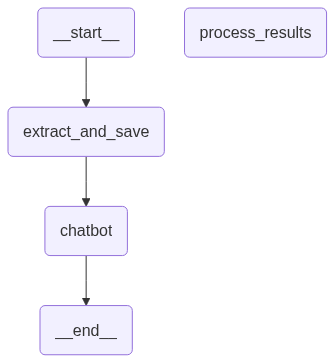

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [12]:
def extract_user_and_message(raw_message: str) -> tuple[str, str]:
    return [value.strip() for value in raw_message.split(":")]

async def handle_message_with_graph(raw_message, history):
    user, message = extract_user_and_message(raw_message)
    print(f"Extracted user: {user}")
    print(f"Extracted message: {message}")
    events = await graph.ainvoke({"messages": [{"role": "user", "content": raw_message}], "input": message, "who": user, "extracted": False, "is_init": False},
    config={"configurable": {"thread_id": 1}})
    print("This is the history: ")
    print(history)
    print("events: ")
    print(events)
    print("printing events: ")
    for event in events["messages"]:
        print("event: ")
        print(event)
    return events["messages"][-1].content

In [13]:
import gradio as gr

present_info, missing_info = render_initial_data_with_priorities(host_inputs, key_priorites)

init_prompt_system = f"""
    You are the world's best travel agent who has information about all the hotels in the world.
                
    Today your goal is to help a group of users choose the right hotel for their needs.
    The entire group wants to travel together and stay at the same hotel.
    
    However, you need certain information from the users to do so.
    This includes destination, number of adults, number of children, number of rooms, start date of trip, end date of trip, amenities required, required bed types, whether or not free breakfast should be included (free_breakfast), what the budget range is as well (max_price and min_price).

    Here's the information you already have:
    {present_info}

    The information you need to make recommendations will be provided next as input. 

    You need to obtain this information with the smallest amount of questions and as quick as possible without appearing like a robot or a form.

    Construct a message to initiate the conversation and start collecting this information in the most human way possible.
"""

init_prompt_user = f"""
    Here's the information you need to collect.
    {missing_info}
"""
    
init_message = await graph.ainvoke({"messages": [{"role": "system", "content": init_prompt_system}, {"role": "user", "content": init_prompt_user}],
                                    "users": {
        "joseph": host_inputs,
        "saawan": HotelSearchRequirements()
    },
    "input": init_prompt_user, "who": "joseph", "is_init": True, "extracted": False, **host_inputs.model_dump()}, config={"configurable": {"thread_id": 1}})

def get_init_message():
    return [{"role": "system", "content": init_message["messages"][-1].content}]

gr.ChatInterface(
    fn=handle_message_with_graph, 
    type="messages",
    chatbot=gr.Chatbot(value=get_init_message, every=gr.Timer(1), type="messages")
).launch()

/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here's the string being returned for available information: 

num_adults: 3
num_children: 0
num_rooms: 2
free_cancelation: True
Here's the string being returned for missing information: 

            destination: The destination where to look for hotels
            
            from_date: Start date of trip
            
            to_date: End date of trip. This is the date till which they want to book the hotel.
            
            amenities: Amenities required
            
            free_breakfast: Is free breakfast required?
            
            max_price: What is the max budget?
            
extract_and_Save called!
prompt being executed: 

                You are the world's best travel agent who has information about all the hotels in the world.
                
                Today your goal is to help a group of users choose the right hotel for their needs.
                The entire group wants to travel together and stay at the same hotel.
                
      

Extracted user: joseph
Extracted message: Amsterdam! 12th June 2025 till 20th June
extract_and_Save called!


Traceback (most recent call last):
  File "/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/gradio/blocks.py", line 2137, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/joat/Documents/Projects/multiuserchat2/env/lib/python3.12/site-packages/gradio/blocks.py", line 1661, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/joat/Documents/Projects/multiuserchat2/en